In [ ]:
import time
notebook_start = time.perf_counter()
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

In [8]:
from thermoift import FeedsBuilder
from pathlib import Path
from itertools import combinations
import pandas as pd, json
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
from matplotlib.ticker import AutoMinorLocator
import thermoift.PLOT_SETTINGS as ps

OUTPUT_DIR = Path("CSV_feeds")
OUTPUT_DIR.mkdir(exist_ok=True)

COMPONENTS  = ["CO2", "H2", "Ar", "N2", "CH4", "O2", "CO", "H2S"]
CO2_LEVELS  = (0.95, 0.96, 0.97, 0.98, 0.99)
SEED        = 550055

builder = FeedsBuilder(rng_type="PCG64")

### 1. Random feeds (Dirichlet sampling)

In [3]:
df_random = builder.generate_random_feeds(
    components=COMPONENTS,
    mixture_sizes=(2, 3),
    co2_levels=CO2_LEVELS,
    n_random_samples=200,
    rng=SEED,
)
print(f"Random feeds: {len(df_random)}")
df_random.head()

Random feeds: 28000


,CO2,H2,Ar,N2,CH4,O2,CO,H2S,mixture_size,active_components,feed_source,template_name
0,0.95,0.05,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",random,dirichlet
1,0.95,0.05,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",random,dirichlet
2,0.95,0.05,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",random,dirichlet
3,0.95,0.05,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",random,dirichlet
4,0.95,0.05,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",random,dirichlet


### 2. Systematic feeds (grid at fixed step)

In [4]:
df_systematic = builder.generate_systematic_feeds(
    components=COMPONENTS,
    mixture_sizes=(2, 3),
    co2_levels=CO2_LEVELS,
    step=0.01,
)
print(f"Systematic feeds: {len(df_systematic)}")
df_systematic.head()

Systematic feeds: 455


,CO2,H2,Ar,N2,CH4,O2,CO,H2S,mixture_size,active_components,feed_source,template_name
0,0.95,0.05,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",systematic,systematic_grid
1,0.96,0.04,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",systematic,systematic_grid
2,0.97,0.03,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",systematic,systematic_grid
3,0.98,0.02,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",systematic,systematic_grid
4,0.99,0.01,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",systematic,systematic_grid


### 3. Industrial feeds (bounds + ranges templates)

In [5]:
builder.load_industrial_templates()

df_ind_bounds = builder.industrial_feeds_from_bounds(
    components=COMPONENTS,
    co2_levels=CO2_LEVELS,
    rng=SEED,
)

df_ind_ranges = builder.industrial_feeds_from_ranges(
    components=COMPONENTS,
    rng=SEED,
)

df_industrial = pd.concat([df_ind_bounds, df_ind_ranges], ignore_index=True)
print(f"Industrial feeds: {len(df_industrial)}  (bounds={len(df_ind_bounds)}, ranges={len(df_ind_ranges)})")
df_industrial.head()

Industrial feeds: 320  (bounds=180, ranges=140)


,CO2,H2,Ar,N2,CH4,O2,CO,H2S,feed_source,template_name,mixture_size,active_components
0,0.95,0.004757,0.002285,0.006029,0.036819,2.318677e-06,0.000033,0.000074,industrial_bound,netl_limits,8,"CO2,O2,H2S,N2,CO,H2,Ar,CH4"
1,0.95,0.003142,0.023756,0.001945,0.021053,3.038671e-07,0.000028,0.000076,industrial_bound,netl_limits,8,"CO2,O2,H2S,N2,CO,H2,Ar,CH4"
2,0.95,0.007844,0.000813,0.013307,0.027990,6.900409e-07,0.000012,0.000033,industrial_bound,netl_limits,8,"CO2,O2,H2S,N2,CO,H2,Ar,CH4"
3,0.95,0.032551,0.000086,0.004813,0.012501,9.827792e-06,0.000024,0.000014,industrial_bound,netl_limits,8,"CO2,O2,H2S,N2,CO,H2,Ar,CH4"
4,0.95,0.029894,0.005380,0.014562,0.000083,5.527114e-06,0.000010,0.000064,industrial_bound,netl_limits,8,"CO2,O2,H2S,N2,CO,H2,Ar,CH4"


### 4. Combined feed (70% random / 20% systematic / 10% industrial)

In [6]:
df_all = builder.combine_feeds_random_systematic_industrial(
    components=COMPONENTS,
    n_total_target=100,
    co2_levels=CO2_LEVELS,
    rng=SEED,
)

print(f"Total feeds: {len(df_all)}")
print()
print(df_all["feed_source"].value_counts())
print()
df_all.head(10)

Total feeds: 100

feed_source
random              70
systematic          20
industrial_range     6
industrial_bound     4
Name: count, dtype: int64



,feed_source,template_name,mixture_size,active_components,CO2,H2,Ar,N2,CH4,O2,CO,H2S
0,random,dirichlet,4,"CO2,H2,O2,CO",0.95,0.005733,0.000000,0.000000,0.000000,0.016922,0.027345,0.000000
1,random,dirichlet,4,"CO2,N2,O2,CO",0.98,0.000000,0.000000,0.009373,0.000000,0.001318,0.009309,0.000000
2,random,dirichlet,5,"CO2,H2,N2,O2,H2S",0.95,0.011916,0.000000,0.013898,0.000000,0.001390,0.000000,0.022796
3,random,dirichlet,5,"CO2,H2,N2,CH4,H2S",0.95,0.000410,0.000000,0.003068,0.024408,0.000000,0.000000,0.022115
4,random,dirichlet,5,"CO2,H2,Ar,O2,H2S",0.98,0.005531,0.005502,0.000000,0.000000,0.007264,0.000000,0.001702
5,random,dirichlet,4,"CO2,Ar,CH4,H2S",0.95,0.000000,0.017390,0.000000,0.023155,0.000000,0.000000,0.009454
6,random,dirichlet,5,"CO2,H2,Ar,N2,CO",0.98,0.006019,0.001055,0.000521,0.000000,0.000000,0.012405,0.000000
7,random,dirichlet,4,"CO2,H2,O2,H2S",0.99,0.003478,0.000000,0.000000,0.000000,0.004631,0.000000,0.001891
8,random,dirichlet,5,"CO2,N2,CH4,O2,H2S",0.95,0.000000,0.000000,0.023563,0.019948,0.001692,0.000000,0.004797
9,random,dirichlet,4,"CO2,CH4,O2,H2S",0.97,0.000000,0.000000,0.000000,0.001084,0.004826,0.000000,0.024090


### 5. Save all feeds

In [7]:
# Save individual feeds
df_random.to_csv(OUTPUT_DIR / "Random_compositions.csv", index=False)
df_systematic.to_csv(OUTPUT_DIR / "Systematic_compositions.csv", index=False)
df_industrial.to_csv(OUTPUT_DIR / "Industrial_compositions.csv", index=False)

# Save combined feed
df_all.to_csv(OUTPUT_DIR / "Combined_compositions.csv", index=False)

print(f"Saved to {OUTPUT_DIR}/:")
print(f"  Random_compositions.csv       : {len(df_random)} rows")
print(f"  Systematic_compositions.csv   : {len(df_systematic)} rows")
print(f"  Industrial_compositions.csv   : {len(df_industrial)} rows")
print(f"  Combined_compositions.csv     : {len(df_all)} rows")

Saved to CSV_feeds/:
  Random_compositions.csv       : 28000 rows
  Systematic_compositions.csv   : 455 rows
  Industrial_compositions.csv   : 320 rows
  Combined_compositions.csv     : 100 rows


### 6. Generate default KIJ pairs config

In [8]:
# Generate default KIJ_pairs.json (all pairs by default set to "zero")

COMPONENTS = ["CO2", "H2", "Ar", "N2", "CH4", "O2", "CO", "H2S"]
pairs = [f"{a}-{b}" for a, b in combinations(COMPONENTS, 2)]
kij_pairs = {pair: "zero" for pair in pairs}

kij_file = OUTPUT_DIR / "KIJ_pairs.json"
with open(kij_file, "w") as f:
    json.dump(kij_pairs, f, indent=2)

print(f"Generated {kij_file} with {len(kij_pairs)} pairs (all set to 'zero')")
print("\nEdit this file to override specific pairs:")
print("  Options: 'zero', 'constant', 'linear'")

Generated CSV_feeds/KIJ_pairs.json with 28 pairs (all set to 'zero')

Edit this file to override specific pairs:
  Options: 'zero', 'constant', 'linear'


In [9]:
elapsed = time.perf_counter() - notebook_start
print(f"\nNotebook runtime: {elapsed:.1f}s")


Notebook runtime: 0.9s


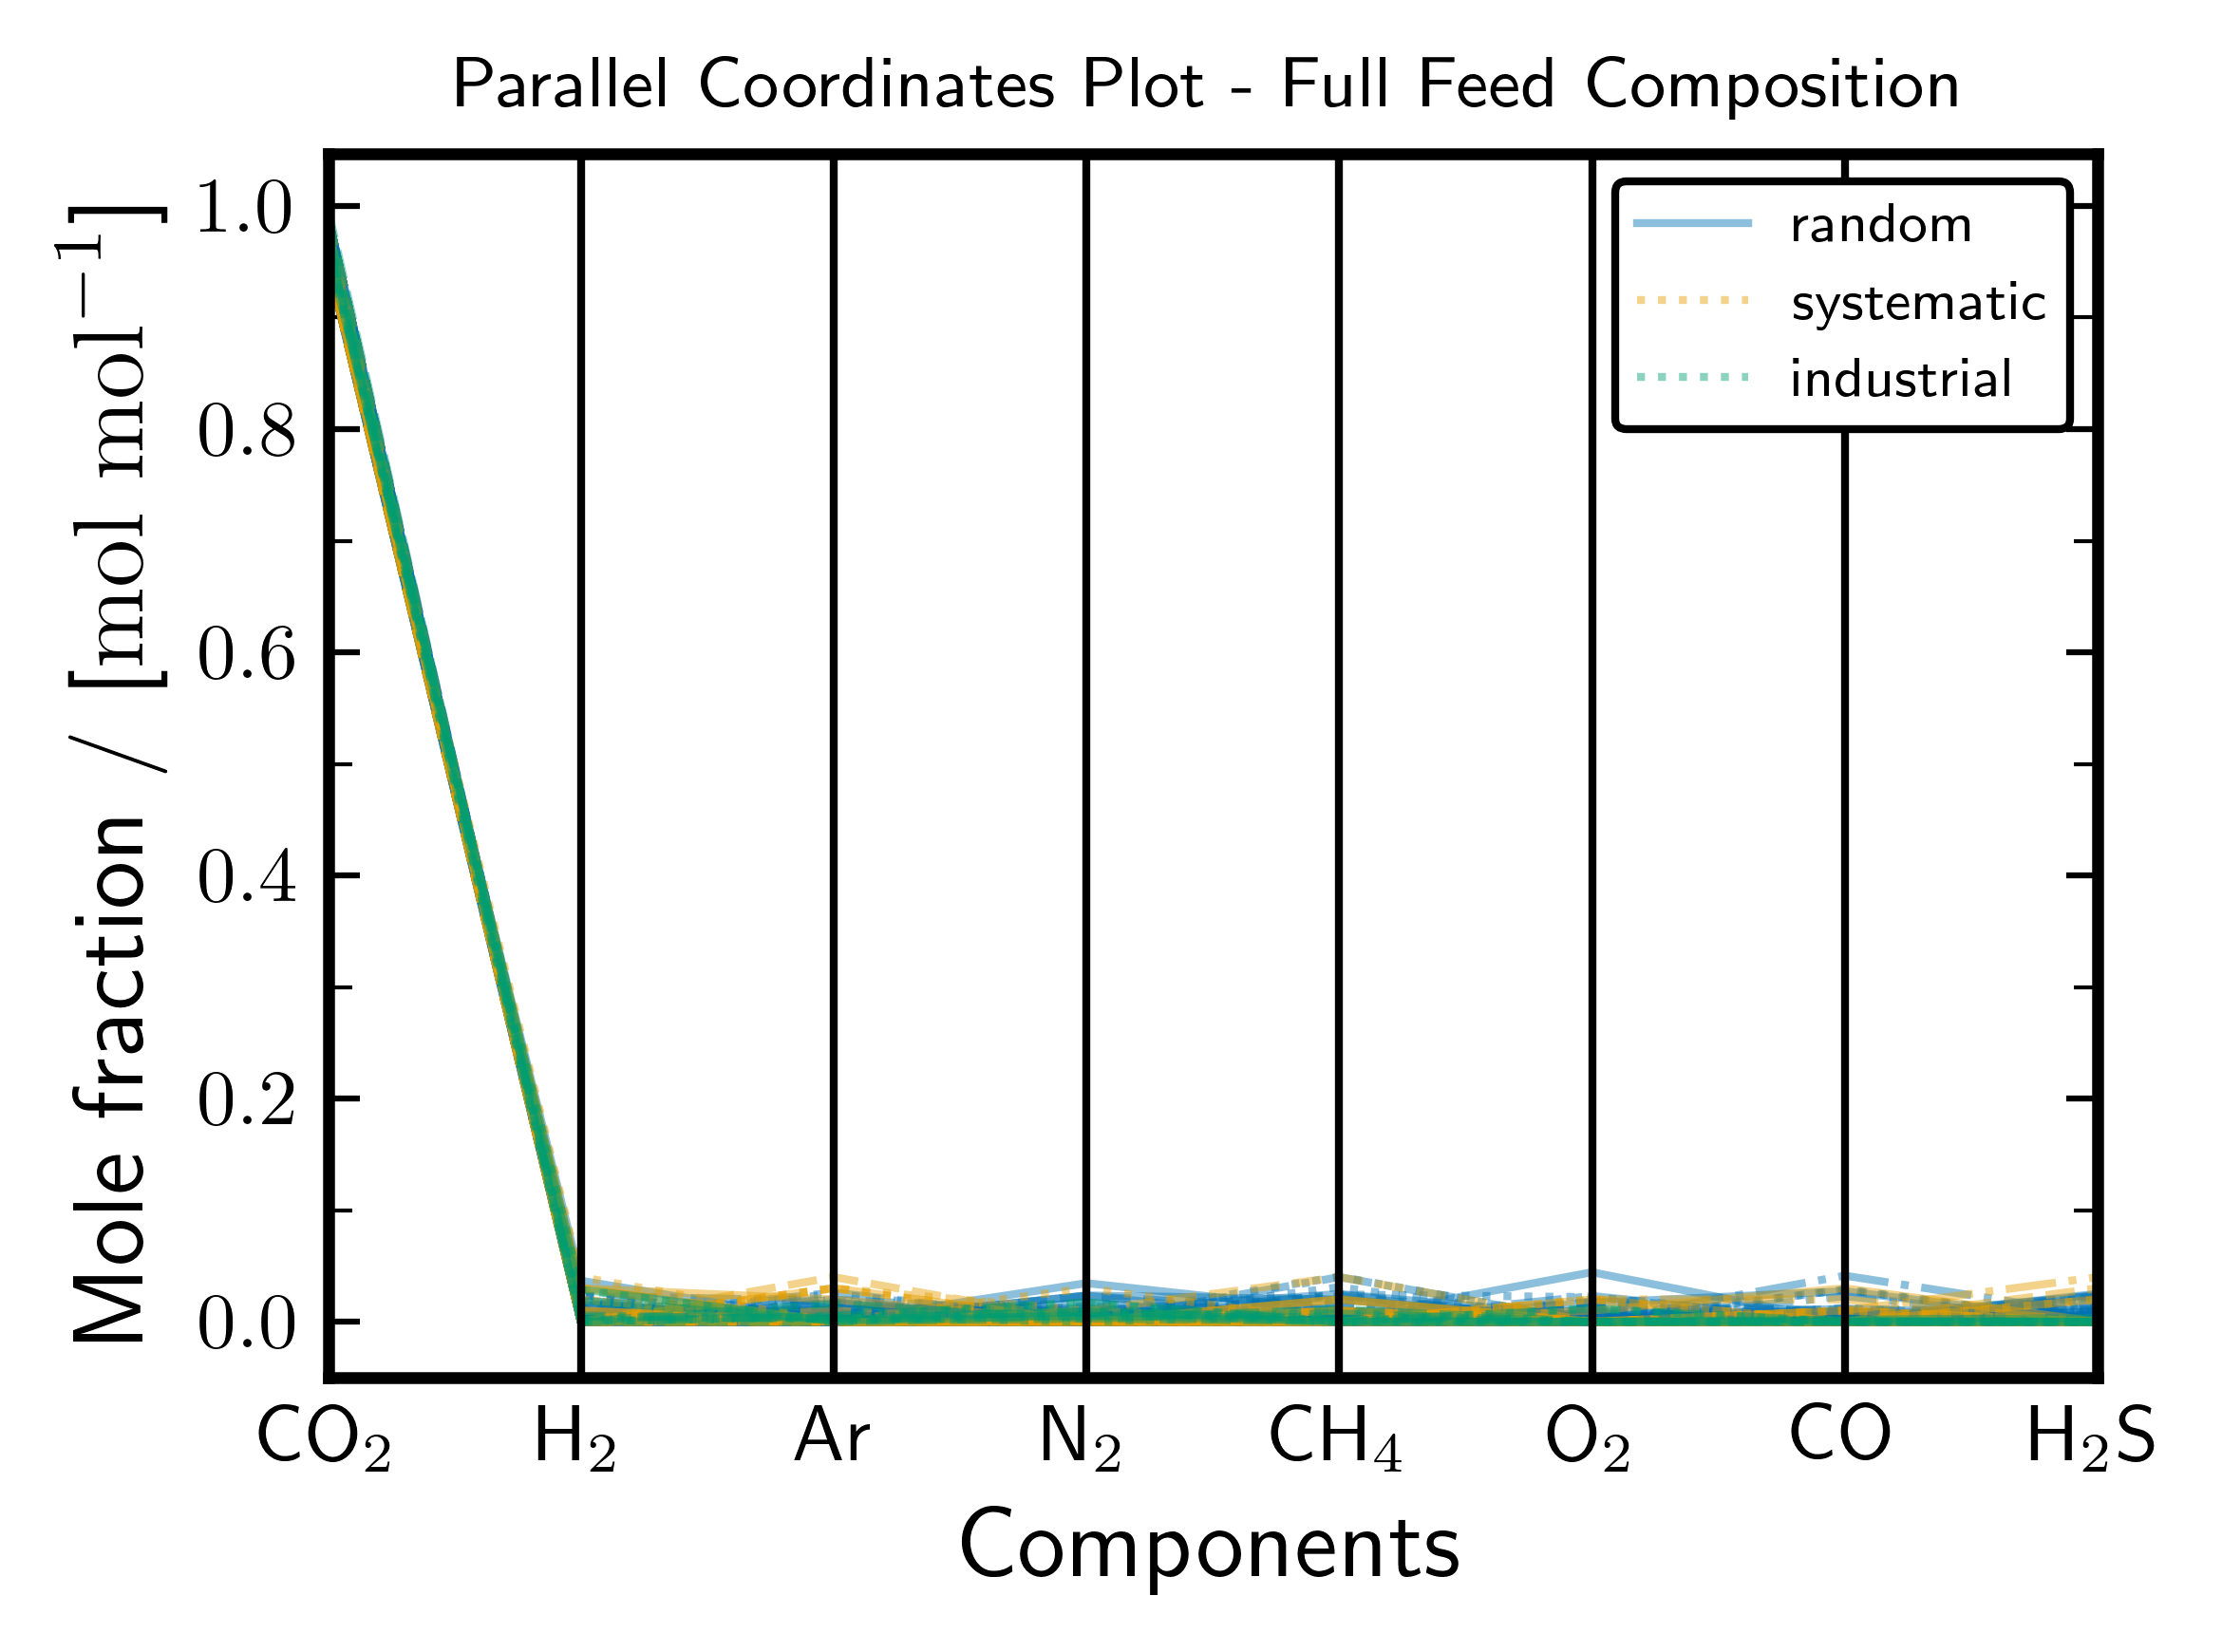

In [25]:
INPUT_FILE = Path("CSV_feeds/Combined_compositions.csv")
df = pd.read_csv(INPUT_FILE)
df["feed_source_plot"] = df["feed_source"].replace({
    "industrial_range": "industrial",
    "industrial_bound": "industrial"
})

comp_cols   = ['CO2', 'H2', 'Ar', 'N2', 'CH4', 'O2', 'CO', 'H2S']
feed        = df[comp_cols].copy()

feed = feed.rename(columns={
    "CO2": r"CO$_2$",
    "H2": r"H$_2$",
    "Ar": r"Ar",
    "N2": r"N$_2$",
    "CH4": r"CH$_4$",
    "O2": r"O$_2$",
    "CO": r"CO",
    "H2S": r"H$_2$S"
})

plot_full = pd.concat(
    [df["feed_source_plot"].rename("group"), feed],
    axis=1
)

# Optional sample
# plot_full = plot_full.sample(min(100, len(plot_full)), random_state=42)

fig, ax = ps.plot_init()

parallel_coordinates(
    plot_full,
    class_column="group",
    ax=ax,
    color=['#0072B2', '#E69F00', '#009E73'],
    alpha=0.45,
    linewidth=1.0
)

ax.set_xlabel("Components", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Mole fraction /  [$\mathrm{mol}\ \mathrm{mol}^{-1}$]", fontsize=ps.label_fontsize * 0.9)
ax.set_title(
    "Parallel Coordinates Plot - Full Feed Composition",
    fontsize=ps.title_fontsize * 0.75,
    fontweight="bold"
)

ps.apply_axis_style(ax)

ax.legend(
    fontsize=ps.label_fontsize * 0.5,
    loc="upper right",
    edgecolor="black",
    facecolor="white",
    framealpha=1.0
)

# ax.minorticks_on()
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.grid(False)
plt.tight_layout()
ps.save_plot(fig, "parallel_coordinates_full")
plt.show()

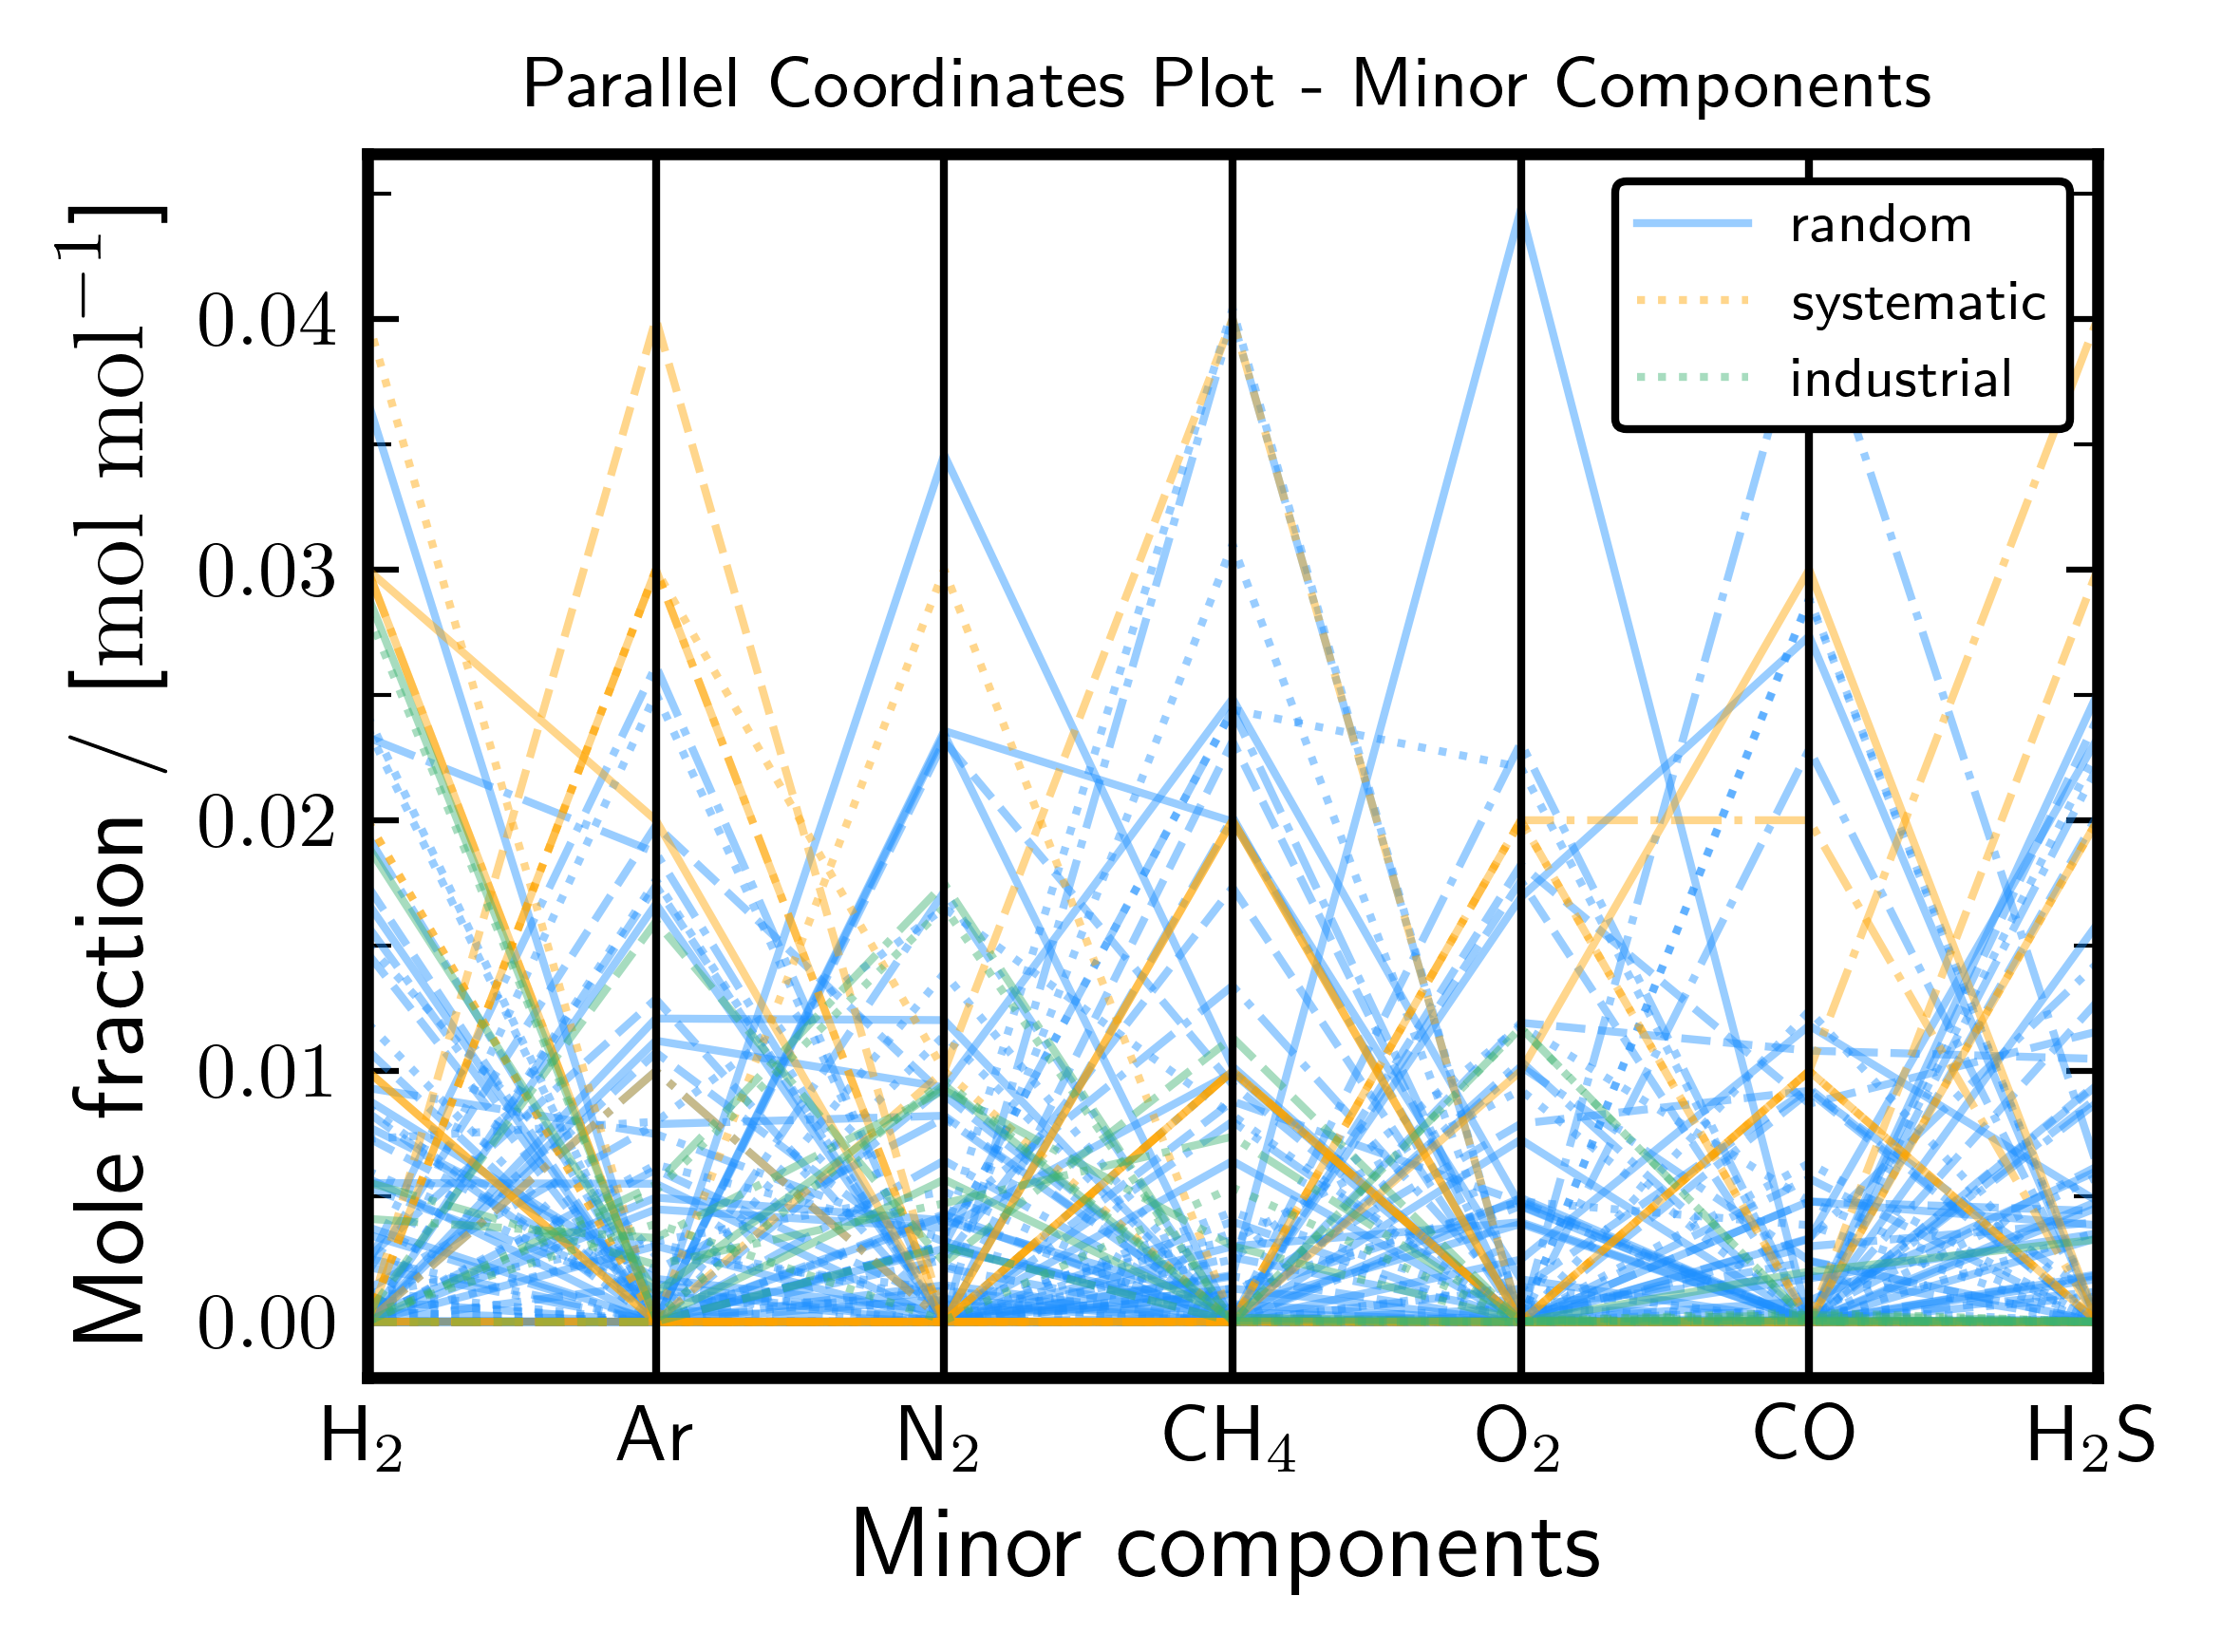

In [26]:
minor_cols = ['H2', 'Ar', 'N2', 'CH4', 'O2', 'CO', 'H2S']
minor = df[minor_cols].copy()
minor = minor.rename(columns={
    "H2":  r"H$_2$",
    "Ar":  r"Ar",
    "N2":  r"N$_2$",
    "CH4": r"CH$_4$",
    "O2":  r"O$_2$",
    "CO":  r"CO",
    "H2S": r"H$_2$S"
})

minor = pd.concat(
    [df["feed_source_plot"].rename("group"), minor],
    axis=1
)

# n_plot_minor = min(100, len(minor))
# minor = minor.sample(n=n_plot_minor, random_state=42)

fig, ax = ps.plot_init()

parallel_coordinates(
    minor,
    class_column="group",
    ax=ax,
    color=['dodgerblue', 'orange', 'mediumseagreen'],
    alpha=0.45,
    linewidth=1.0
)

ax.set_xlabel("Minor components", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Mole fraction /  [$\mathrm{mol}\ \mathrm{mol}^{-1}$]", fontsize=ps.label_fontsize * 0.9)
ax.set_title(
    "Parallel Coordinates Plot - Minor Components",
    fontsize=ps.title_fontsize * 0.75,
    fontweight="bold"
)

ps.apply_axis_style(ax)
ax.legend(
    fontsize=ps.label_fontsize * 0.5,
    loc="upper right",
    edgecolor="black",
    facecolor="white",
    framealpha=1.0
)

# ax.minorticks_on()
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.grid(False)
plt.tight_layout()
ps.save_plot(fig, "parallel_coordinates_minor")
plt.show()